# Session 1 - Thinking Like a Data Scientist

## Property Finder Egypt: Residential Buy Price Prediction

Today is not about winning a Kaggle competition.

Today is about learning how a Data Scientist thinks when a real dataset arrives for the first time.

We will move slowly, ask questions, inspect evidence, make simple decisions, and build our first machine learning models.

## 1. Business Understanding

### What business problem are we solving?

Before we touch the CSV file, we need to understand the situation.

Property Finder is a real estate platform where people browse listings for apartments, villas, chalets, and other properties.

Our dataset contains residential properties listed for sale in Egypt.

The business question is simple:

Can we estimate the asking price of a property using information from the listing?

This is a regression problem because the value we want to predict is a number: the property price.

### What should we conclude?

Our target is `price`.

That means every later decision should protect the meaning of this target. We should not accidentally use columns that already contain the answer, and we should not clean the data blindly without asking what each row represents.

## 2. Loading the Dataset

### What tools do we need first?

We will use the libraries practitioners use for inspection and visualization.

For machine learning, we will use a small part of scikit-learn. Nothing fancy yet.

In [79]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

### What should we conclude?

These imports are enough for Session 1.

Notice that we are not importing advanced tools yet. A beginner project should first build judgment, not complexity.

In [80]:

df = pd.read_csv(r'DATA\processed\buy.csv')

### What should we conclude?

The dataset is now loaded into `df`.

From this point, every operation should help us answer a question about the data or prepare the data for a simple first model.

### What does the first small sample look like?

Before using summaries, we should simply look at a few rows.

This helps us connect column names to real listing information.

In [81]:
df.head()

,id,title,price,currency,price_period,price_type,price_raw_value,property_type,location,latitude,longitude,images,share_url,bedrooms,bathrooms,size,amenities,category,page,scraped_at_utc,record_type
0,8572018,SEA VIEW chalet ( 3 bedrooms ) - RTM - Foukabay,11350000.0,EGP,sell,sale_price,11350000,Chalet,"Fouka Bay, Qesm Marsa Matrouh, North Coast",31.090607,27.940727,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/buy/chale...,3.0,2.0,129,['BA'],buy,1,2026-02-19T14:59:11.753113+00:00,property
1,8698066,"Ready to move garden apt 140 sqm , 8 years plan.",800000.0,EGP,sell,sale_price,800000,Apartment,"Mountain View iCity, 5th Settlement Compounds,...",30.069424,31.599737,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/buy/apart...,2.0,2.0,140,"['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...",buy,1,2026-02-19T14:59:11.753113+00:00,property
2,8572009,TWIN HOUSE ( SEA VIEW ) 360 m For sale at D-Bay,23000000.0,EGP,sell,sale_price,23000000,Twin House,"D-Bay, Qesm Ad Dabaah, North Coast",31.080320,28.393543,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/buy/twin-...,5.0,6.0,360,"['BA', 'BW', 'CP', 'BK', 'MR', 'PG', 'SP', 'VW...",buy,1,2026-02-19T14:59:11.753113+00:00,property
3,52721554,"Ready garden apart 158 sqm in Beverly, 5yrs plan",5600000.0,EGP,sell,sale_price,5600000,Apartment,"Six West, Beverly Hills, Sheikh Zayed Compound...",30.071228,30.936045,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/buy/apart...,2.0,3.0,158,"['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...",buy,1,2026-02-19T14:59:11.753113+00:00,property
4,8651935,Pay 52K per month&Get Finished Apartment in Zayed,NaN,EGP,sell,suspicious_low,155220,Apartment,"Village West, Sheikh Zayed Compounds, Sheikh Z...",30.048094,31.020054,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/buy/apart...,3.0,3.0,200,"['BA', 'BW', 'CP', 'SP', 'SE', 'SS', 'ST', 'WC...",buy,1,2026-02-19T14:59:11.753113+00:00,property


### What should we conclude?

Each row looks like a real listing.

We can already see useful information such as `price`, `property_type`, `location`, `bedrooms`, `bathrooms`, and `size`.

We can also see columns that may not help a first model, such as URLs, image links, and scrape metadata.

## 3. First Look at the Dataset

### What did we actually receive?

The first question is not about cleaning.

The first question is: how big is this dataset, and how many pieces of information do we have for each listing?

In [82]:
df.shape

(19967, 21)

### What should we conclude?

The shape gives us two things:

- number of rows: how many listings we received
- number of columns: how many fields describe each listing

This dataset is large enough for a meaningful beginner ML project, but still small enough to explore comfortably in a workshop.

### What columns did we receive?

Column names are our first map of the dataset.

Before cleaning, we need to know what options are available.

In [83]:
df.columns

Index(['id', 'title', 'price', 'currency', 'price_period', 'price_type',
       'price_raw_value', 'property_type', 'location', 'latitude', 'longitude',
       'images', 'share_url', 'bedrooms', 'bathrooms', 'size', 'amenities',
       'category', 'page', 'scraped_at_utc', 'record_type'],
      dtype='object')

### What should we conclude?

Some columns describe the property itself, like `property_type`, `bedrooms`, `bathrooms`, and `size`.

Some columns describe the listing source, like `share_url`, `images`, `page`, and `scraped_at_utc`.

A Data Scientist must separate useful predictive information from technical metadata.

### What are the data types and missing counts?

`info()` is useful because it answers two questions at the same time:

What type does pandas think each column is?

How many non-missing values does each column have?

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19967 entries, 0 to 19966
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               19967 non-null  int64  
 1   title            19967 non-null  object 
 2   price            19965 non-null  float64
 3   currency         19967 non-null  object 
 4   price_period     19967 non-null  object 
 5   price_type       19967 non-null  object 
 6   price_raw_value  19967 non-null  int64  
 7   property_type    19967 non-null  object 
 8   location         19967 non-null  object 
 9   latitude         19967 non-null  float64
 10  longitude        19967 non-null  float64
 11  images           19967 non-null  object 
 12  share_url        19967 non-null  object 
 13  bedrooms         19402 non-null  float64
 14  bathrooms        19937 non-null  float64
 15  size             19967 non-null  int64  
 16  amenities        19967 non-null  object 
 17  category    

### What should we conclude?

We should look for surprises.

For test setple, `bedrooms` and `bathrooms` may appear as floats because they contain missing values. That does not mean bedrooms are decimal numbers. It means pandas needed a way to represent missing values.

This is why data types are part of data quality, not just a technical detail.

### What do the numeric columns look like?

`describe()` gives us a quick statistical summary.

We are not trying to memorize the numbers. We are looking for strange minimums, maximums, and ranges.

In [85]:
df.describe()

,id,price,price_raw_value,latitude,longitude,bedrooms,bathrooms,size,page
count,1.996700e+04,1.996500e+04,1.996700e+04,19967.000000,19967.000000,19402.000000,19937.000000,19967.000000,19967.000000
mean,3.865041e+07,1.592950e+07,1.592792e+07,29.831217,31.350773,3.079425,2.957466,197.663345,400.371813
std,2.035687e+07,2.587948e+07,2.587866e+07,0.944462,1.256729,1.115619,1.288219,254.287726,231.006963
min,3.298010e+06,2.000000e+05,1.000000e+05,25.526726,25.476135,1.000000,1.000000,1.000000,1.000000
25%,8.708714e+06,5.696000e+06,5.696000e+06,29.984762,30.990543,2.000000,2.000000,112.000000,200.000000
50%,5.219595e+07,1.000000e+07,1.000000e+07,30.024607,31.506924,3.000000,3.000000,165.000000,400.000000
75%,5.246293e+07,1.800000e+07,1.800000e+07,30.069866,31.613102,4.000000,4.000000,235.000000,600.500000
max,5.297418e+07,1.000000e+09,1.000000e+09,31.497467,34.632736,7.000000,7.000000,21000.000000,800.000000


### What should we conclude?

The price and size ranges are very wide.

That is normal in real estate, but it also means our models may make large errors on expensive or unusual properties.

This is an early warning: evaluation must be interpreted in business language, not just as a score.

## 4. Can We Trust the Dataset?

### Are there missing values?

Missing values are not automatically bad.

But we need to know where they are, because different missing values mean different things.

A missing `price` is serious because price is our target. A missing `bedrooms` may mean the listing is incomplete or the property type does not use bedrooms in the normal way.

In [86]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
bedrooms,565,2.83
bathrooms,30,0.15
price,2,0.01
id,0,0.00
images,0,0.00
scraped_at_utc,0,0.00
page,0,0.00
category,0,0.00
amenities,0,0.00
size,0,0.00


### What should we conclude?

We should not use one rule for every column.

A missing target price usually means the row cannot be used for supervised training.

Missing bedrooms or bathrooms need judgment. In Session 1, we will keep the decision simple and transparent.

### Are there duplicated rows?

Duplicate rows can make a model look better than it really is.

If the same listing appears in both training and test data, the model is partly being tested on something it has already seen.

In [87]:
df.duplicated().sum()

0

### What should we conclude?

If this number is zero, great.

If it is not zero, we should remove exact duplicates before modeling.

Even when the answer is zero, the check is still useful because it proves we looked.

### Does every row represent a unique property listing?

Exact duplicate rows are one thing.

Duplicate IDs are another. If `id` is supposed to identify a listing, it should be unique.

In [88]:
id_check = pd.Series({
    "number_of_rows": len(df),
    "unique_ids": df["id"].nunique(),
    "duplicated_ids": df["id"].duplicated().sum()
})

id_check

number_of_rows    19967
unique_ids        19967
duplicated_ids        0
dtype: int64

### What should we conclude?

If `unique_ids` equals the number of rows, each listing has a unique identifier.

That is good for tracking rows, but `id` should not be used as a model feature. It is a label, not a property characteristic.

### Are the data types correct?

Machine learning models care about numbers and categories.

So we need to ask whether each column is stored in a useful format.

In [89]:
df.dtypes

id                   int64
title               object
price              float64
currency            object
price_period        object
price_type          object
price_raw_value      int64
property_type       object
location            object
latitude           float64
longitude          float64
images              object
share_url           object
bedrooms           float64
bathrooms          float64
size                 int64
amenities           object
category            object
page                 int64
scraped_at_utc      object
record_type         object
dtype: object

### What should we conclude?

Some columns are already numeric, such as `price`, `size`, `latitude`, and `longitude`.

Some columns are text categories, such as `property_type` and `location`.

Some columns look numeric but are not useful as model inputs, such as `id`.

This is why type checking does not replace human thinking.

### Are some columns constant or almost constant?

A column that has the same value in every row cannot help the model separate expensive properties from cheaper ones.

It may still be useful for documentation, but not for prediction.

In [90]:
unique_counts = df.nunique().sort_values()
unique_counts

record_type            1
category               1
currency               1
price_period           1
price_type             2
bathrooms              7
bedrooms               7
property_type         17
size                 681
page                 800
scraped_at_utc      1039
latitude            1368
longitude           1369
location            1503
price               4291
price_raw_value     4293
amenities           9482
title              17459
images             19967
share_url          19967
id                 19967
dtype: int64

### What should we conclude?

Columns like `currency`, `price_period`, `category`, and `record_type` may be constant in this file.

That makes sense because this file is already residential buy listings in Egypt.

For this first model, constant columns do not add predictive information.

### Is there any target leakage hiding in the columns?

Target leakage means giving the model information that would not be available when making a real prediction.

Here, `price_raw_value` is very close to the target price, so it should not be used as an input feature.

In [91]:
df[["price", "price_raw_value", "price_type"]].head(10)

,price,price_raw_value,price_type
0,11350000.0,11350000,sale_price
1,800000.0,800000,sale_price
2,23000000.0,23000000,sale_price
3,5600000.0,5600000,sale_price
4,NaN,155220,suspicious_low
5,3500000.0,3500000,sale_price
6,4400000.0,4400000,sale_price
7,1100000.0,1100000,sale_price
8,68000000.0,68000000,sale_price
9,40000000.0,40000000,sale_price


### What should we conclude?

`price_raw_value` is not a normal property feature.

It is price information from the scraped listing. If we use it to predict `price`, the model is basically being given the answer.

We will exclude it from model features.

### Are there suspicious values in property size?

Real data often contains values that are technically numbers but do not make business sense.

For test setple, a villa with size 2 square meters is not a real villa size. It may represent a data-entry issue, a down-payment style listing, or a scraped value that does not mean area.

In [92]:
size_quantiles = df["size"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])
size_quantiles

0.00        1.0
0.01       20.0
0.05       20.0
0.25      112.0
0.50      165.0
0.75      235.0
0.95      450.0
0.99      850.0
1.00    21000.0
Name: size, dtype: float64

### What should we conclude?

The size column has a very wide range.

Large values may be land or luxury properties. Small values below a realistic residential area are more suspicious.

We should inspect suspicious rows before deleting anything.

### What do the tiny-size rows look like?

Instead of deleting rows immediately, we inspect test setples.

This is the habit we want engineers to build: look, then decide.

In [93]:
 df.loc[df["size"] < 20, ["id", "title", "price", "property_type", "bedrooms", "bathrooms", "size"]].head(10)


,id,title,price,property_type,bedrooms,bathrooms,size
920,8708072,"Down 800,000= own 3-bed, full sea view &prime ...",900000.0,Chalet,3.0,3.0,10
921,8708064,Small Villa136m Finished+ACs Sea View Best Loc...,1890000.0,Villa,2.0,2.0,2
923,8707925,Sea View Chalet148m Finished+ACs DP1.495.000,1495000.0,Chalet,2.0,2.0,2
936,8693386,"DP900k,villa(170m+garden+roof+pool)finished-ta...",900000.0,Villa,4.0,4.0,10
937,8683676,"DP950k,duplex(235m+garden 174m)near cairo fest...",950000.0,Duplex,5.0,4.0,10
939,8707672,Finished+ACs Chalet Direct Lagoon View DP 1M,1000000.0,Chalet,1.0,1.0,2
1045,8392258,"Finished 100m, Full sea view, Lowest DP, till ...",5900000.0,Chalet,1.0,1.0,10
1285,8627854,DP 287k chalet(95m)(sea 1st row+lagoon view+fi...,287000.0,Chalet,2.0,2.0,6
1595,8678182,"DP 800k,villa(166m+garden+pool)full finishd-ta...",800000.0,Villa,4.0,4.0,10
1597,8674978,"Pay 1,5M+plan 8y! Double-view villa Park & Water",1500000.0,Villa,7.0,7.0,14


### What should we conclude?

Some tiny sizes appear with normal property types and multiple rooms.

That does not look like a real area measurement.

For this beginner model, we will remove rows where `size` is below 20 square meters. This is a simple, explainable rule. In a professional project, we would discuss this threshold with a domain expert.

## 5. Exploratory Data Analysis

### How is price distributed?

Price is the target, so we start there.

Real estate prices are often skewed: many normal properties and a smaller number of very expensive ones.

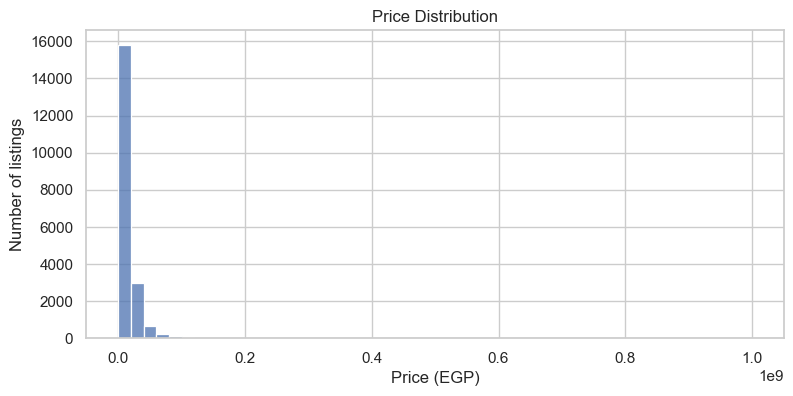

In [94]:
plt.figure(figsize=(9, 4))
sns.histplot(df["price"].dropna(), bins=50)
plt.title("Price Distribution")
plt.xlabel("Price (EGP)")
plt.ylabel("Number of listings")
plt.show()

### What should we conclude?

The chart is usually squeezed because a few very expensive properties stretch the x-axis.

That does not mean the chart failed. It tells us the target is skewed.

This affects modeling because errors on luxury properties may be much larger in absolute EGP.

### What happens if we view price on a log scale?

A log scale helps us see the body of a skewed distribution more clearly.

We are not changing the data here. We are changing how we look at it.

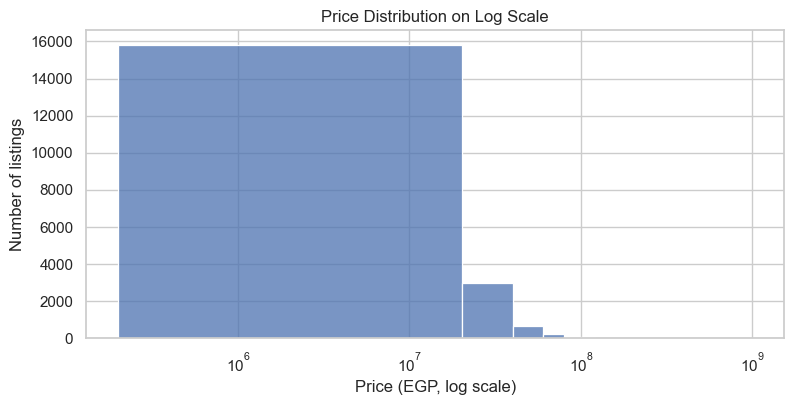

In [95]:
plt.figure(figsize=(9, 4))
sns.histplot(df["price"].dropna(), bins=50)
plt.xscale("log")
plt.title("Price Distribution on Log Scale")
plt.xlabel("Price (EGP, log scale)")
plt.ylabel("Number of listings")
plt.show()

### What should we conclude?

Most properties are concentrated in a more normal-looking range once we use log scale.

This is a useful EDA trick. It helps us understand skewed variables without immediately changing the modeling target.

### How is property size distributed?

Size should matter a lot for price.

But first, we need to see whether size itself has strange behavior.

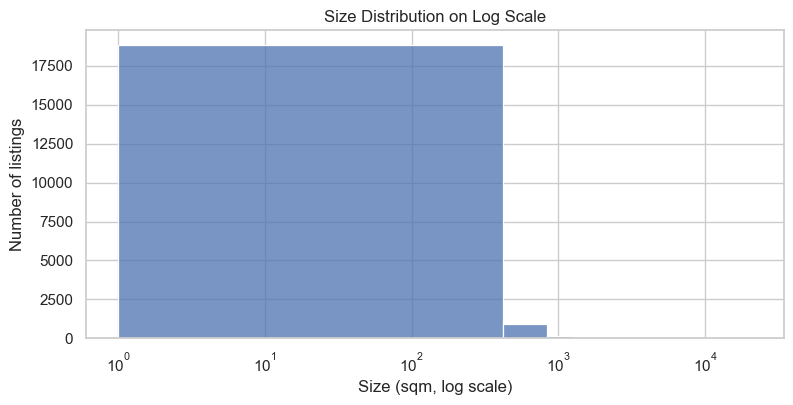

In [96]:
plt.figure(figsize=(9, 4))
sns.histplot(df["size"], bins=50)
plt.xscale("log")
plt.title("Size Distribution on Log Scale")
plt.xlabel("Size (sqm, log scale)")
plt.ylabel("Number of listings")
plt.show()

### What should we conclude?

Most listings are in a reasonable residential size range, but there are very small and very large values.

This confirms that cleaning size should be a decision, not an automatic step.

### Which property types appear most often?

Property type changes the meaning of size, rooms, and price.

An apartment and a villa with the same area may not have the same price behavior.

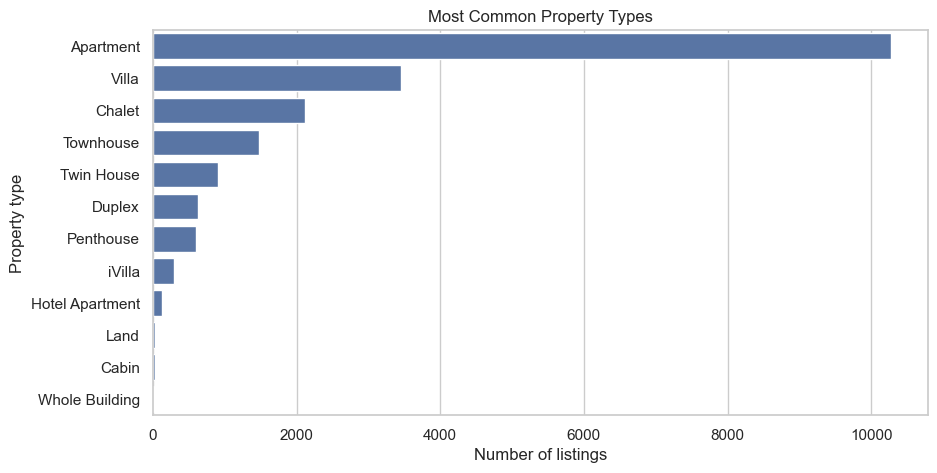

In [97]:
plt.figure(figsize=(10, 5))
property_type_counts = df["property_type"].value_counts().head(12)
sns.barplot(x=property_type_counts.values, y=property_type_counts.index)
plt.title("Most Common Property Types")
plt.xlabel("Number of listings")
plt.ylabel("Property type")
plt.show()

### What should we conclude?

The dataset is not balanced across property types.

Apartments usually dominate residential listings, while rare categories may have very few test setples.

This matters because a model learns better from categories that have enough data.

### How many bedrooms do listings usually have?

Bedrooms are a simple feature, but they carry strong business meaning.

Families, investors, and brokers all care about room count.

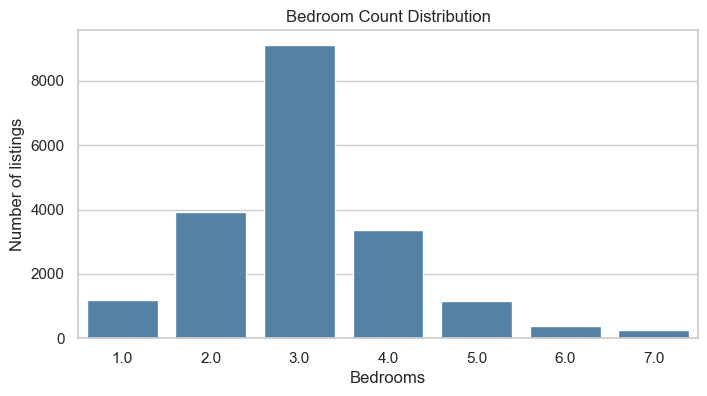

In [98]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="bedrooms", color="steelblue")
plt.title("Bedroom Count Distribution")
plt.xlabel("Bedrooms")
plt.ylabel("Number of listings")
plt.show()

### What should we conclude?

Most listings have a small number of bedrooms, which is expected for residential properties.

If we see missing values or unusual room counts, we should handle them before modeling.

### How many bathrooms do listings usually have?

Bathrooms are another basic property feature.

It often moves with bedrooms and property size.

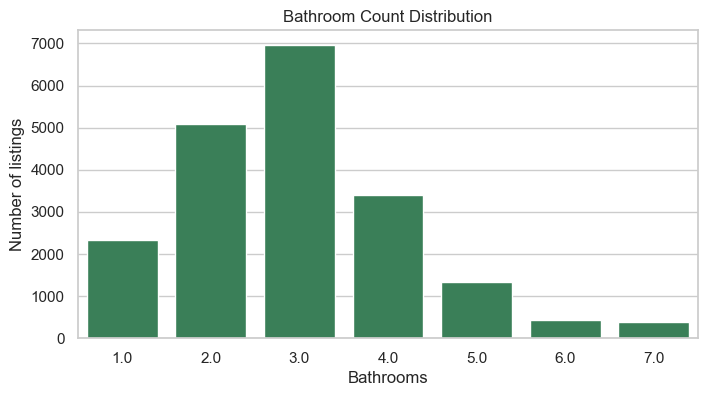

In [99]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="bathrooms", color="seagreen")
plt.title("Bathroom Count Distribution")
plt.xlabel("Bathrooms")
plt.ylabel("Number of listings")
plt.show()

### What should we conclude?

Bathroom count has a similar practical meaning to bedrooms.

It may help the model, but it may also overlap with size and property type. That is normal. Models can use overlapping signals, but we should know they are related.

### Where are listings located?

Location is one of the most important drivers of property price.

The `location` column is detailed, but for a beginner model we can start by extracting the last part, which usually represents the governorate or broad area.

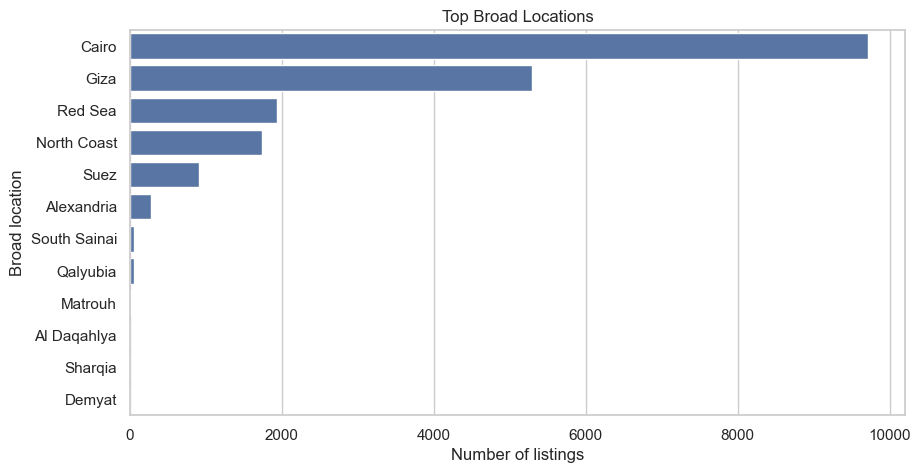

In [100]:
governorate_preview = df["location"].str.split(",").str[-1].str.strip()

top_governorates = governorate_preview.value_counts().head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_governorates.values, y=top_governorates.index)
plt.title("Top Broad Locations")
plt.xlabel("Number of listings")
plt.ylabel("Broad location")
plt.show()

### What should we conclude?

Some locations have many more listings than others.

This affects both EDA and modeling. A model may learn more reliable patterns for Cairo and Giza than for locations with only a few rows.

### Does area relate to price?

A larger property usually costs more, but real estate is never controlled by size alone.

This plot helps us see the relationship and the noise around it.

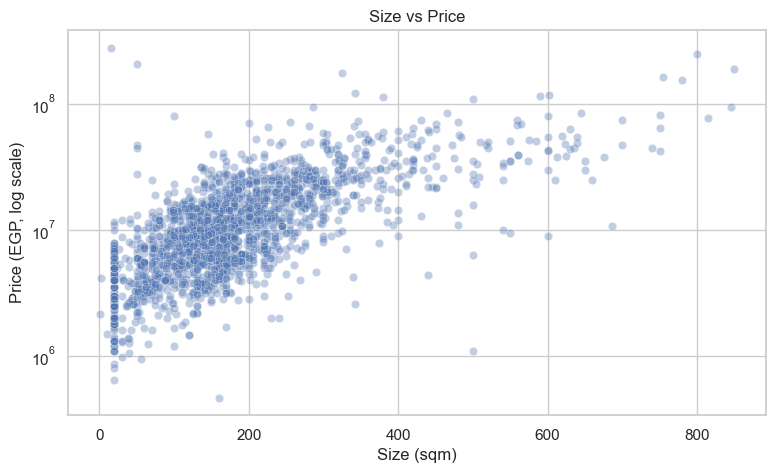

In [101]:
plot_data = df.dropna(subset=["price", "size"]).copy()
plot_data = plot_data[plot_data["size"] <= plot_data["size"].quantile(0.99)]
plot_data = plot_data.sample(min(2000, len(plot_data)), random_state=42)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_data, x="size", y="price", alpha=0.35)
plt.yscale("log")
plt.title("Size vs Price")
plt.xlabel("Size (sqm)")
plt.ylabel("Price (EGP, log scale)")
plt.show()

### What should we conclude?

There is a relationship between size and price, but it is not a perfect line.

That makes sense. Two apartments with the same size can have very different prices depending on location, finishing, compound, view, payment plan, and property type.

This is why we need multiple features.

## 6. Cleaning

### What should we clean after understanding the data?

Now we clean.

Notice the order: we inspected first, then decided.

Cleaning is not a checklist. Cleaning is a response to evidence.

In [102]:
df_clean = df.copy()

print("Rows before cleaning:", len(df_clean))

Rows before cleaning: 19967


### What should we conclude?

We create `df_clean` so the original `df` remains untouched.

This is useful in teaching and in real projects because we may want to compare before and after cleaning.

### Should we remove exact duplicate rows?

Duplicates can distort model evaluation.

Even if this dataset has no duplicates, the cleaning step is still valid because it documents the check.

In [103]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates()

rows_after = len(df_clean)
print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

Rows removed: 0
Rows remaining: 19967


### What should we conclude?

If zero rows were removed, that is good news.

The important idea is that we checked and made the result visible.

### Can we train a supervised model without the target price?

No.

For supervised learning, each training row needs an answer. Here the answer is `price`.

In [104]:
rows_before = len(df_clean)

df_clean = df_clean.dropna(subset=["price"])
df_clean = df_clean[df_clean["price"] > 0]

rows_after = len(df_clean)
print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

Rows removed: 2
Rows remaining: 19965


### What should we conclude?

Rows without a valid price cannot be used to train a price prediction model.

We removed them because the reason is clear and directly connected to the ML problem.

### What should we do with missing bedrooms and bathrooms?

There are several possible strategies:

- drop rows with missing room counts
- fill missing values with median values
- create a missing-value flag
- treat some property types separately

For Session 1, we choose the simplest transparent option: drop rows missing bedrooms or bathrooms.

This is acceptable here because the missing percentage is small and we focus on the full project flow.

In [105]:
rows_before = len(df_clean)

missing_rooms_before = df_clean[["bedrooms", "bathrooms"]].isna().sum()
df_clean = df_clean.dropna(subset=["bedrooms", "bathrooms"])

rows_after = len(df_clean)
print(missing_rooms_before)
print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

bedrooms     565
bathrooms     30
dtype: int64
Rows removed: 565
Rows remaining: 19400


### What should we conclude?

This is not the only correct strategy.

It is a beginner-friendly decision that keeps the first model easy to understand.

In a later session, we can compare this with imputation.

### Which suspicious size values are obvious enough to remove?

We saw listings with sizes like 1, 2, or 10 square meters while having multiple bedrooms.

For a residential price model, these are not realistic property areas.

In [106]:
rows_before = len(df_clean)

df_clean = df_clean[df_clean["size"] >= 20].copy()

rows_after = len(df_clean)
print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

Rows removed: 81
Rows remaining: 19319


### What should we conclude?

We removed only the most obvious size problems.

We did not remove expensive properties just because they are expensive, and we did not remove large properties just because they are rare.

That is an important distinction.

### Do numeric columns now have useful types?

After removing missing room counts, bedrooms and bathrooms can be converted from floats to integers.

This makes the data easier to read and explain.

In [107]:
df_clean["bedrooms"] = df_clean["bedrooms"].astype(int)
df_clean["bathrooms"] = df_clean["bathrooms"].astype(int)
df_clean["scraped_at_utc"] = pd.to_datetime(df_clean["scraped_at_utc"])

df_clean[["bedrooms", "bathrooms", "scraped_at_utc"]].dtypes


bedrooms                        int32
bathrooms                       int32
scraped_at_utc    datetime64[ns, UTC]
dtype: object

### What should we conclude?

This conversion is not about making the model smarter.

It is about making the data representation match the real meaning of the columns.

### How much data did we keep?

Cleaning should always have an audit trail.

If we remove rows, we should know how many.

In [128]:
df["scraped_at_utc"].head(10)

0    2026-02-19T14:59:11.753113+00:00
1    2026-02-19T14:59:11.753113+00:00
2    2026-02-19T14:59:11.753113+00:00
3    2026-02-19T14:59:11.753113+00:00
4    2026-02-19T14:59:11.753113+00:00
5    2026-02-19T14:59:11.753113+00:00
6    2026-02-19T14:59:11.753113+00:00
7    2026-02-19T14:59:11.753113+00:00
8    2026-02-19T14:59:11.753113+00:00
9    2026-02-19T14:59:11.753113+00:00
Name: scraped_at_utc, dtype: object

In [108]:
cleaning_summary = pd.Series({
    "original_rows": len(df),
    "clean_rows": len(df_clean),
    "rows_removed": len(df) - len(df_clean),
    "percent_removed": round((len(df) - len(df_clean)) / len(df) * 100, 2)
})

cleaning_summary

original_rows      19967.00
clean_rows         19319.00
rows_removed         648.00
percent_removed        3.25
dtype: float64

### What should we conclude?

We kept most of the dataset.

The goal was not to make the data perfect. The goal was to remove rows that clearly block or confuse a first supervised learning model.

## 7. Simple Feature Engineering

### Can location become easier for a beginner model?

The full `location` field is detailed and high-cardinality.

For Session 1, we will extract the last part of the location string as a broad location feature.

This gives the model simple location information without creating thousands of neighborhood columns.

In [109]:
df_clean["governorate"] = df_clean["location"].str.split(",").str[-1].str.strip()

df_clean[["location", "governorate"]].head()

,location,governorate
0,"Fouka Bay, Qesm Marsa Matrouh, North Coast",North Coast
1,"Mountain View iCity, 5th Settlement Compounds,...",Cairo
2,"D-Bay, Qesm Ad Dabaah, North Coast",North Coast
3,"Six West, Beverly Hills, Sheikh Zayed Compound...",Giza
5,"El Patio 7, 5th Settlement Compounds, The 5th ...",Cairo


### What should we conclude?

We gave the model a simpler version of location.

This is not perfect, but it is understandable and useful for a first project.

### Can amenities become a number?

The `amenities` column stores a list-like text value.

A model cannot directly understand that text list, but it can understand a count.

The question is: does a listing with more amenities tend to have more value?

In [110]:
df_clean["amenities"].head()

0                                               ['BA']
1    ['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...
2    ['BA', 'BW', 'CP', 'BK', 'MR', 'PG', 'SP', 'VW...
3    ['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...
5    ['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...
Name: amenities, dtype: object

### What should we conclude?

The values look like Python lists stored as text.

We can safely convert each text list into an actual list using `ast.literal_eval`, then count the items.

### What new information are we giving the model?

By creating `amenities_count`, we are not asking the model to understand every amenity code.

We are giving it a simple signal: how many amenities are mentioned in the listing.

In [111]:
df_clean["amenities_count"] = df_clean["amenities"].apply(
    lambda value: len(ast.literal_eval(value)) if pd.notna(value) else 0
)

df_clean[["amenities", "amenities_count"]].head()

,amenities,amenities_count
0,['BA'],1
1,"['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...",13
2,"['BA', 'BW', 'CP', 'BK', 'MR', 'PG', 'SP', 'VW...",16
3,"['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...",13
5,"['BA', 'BW', 'CP', 'PG', 'SP', 'VW', 'SE', 'SS...",13


### What should we conclude?

This feature is simple and explainable.

It may not capture the difference between a pool and a balcony, but it gives the model a useful first signal.

### Can we summarize room information?

Bedrooms and bathrooms are separate features.

Sometimes a simple combined feature can help the model understand property scale.

In [112]:
df_clean["total_rooms"] = df_clean["bedrooms"] + df_clean["bathrooms"]

df_clean[["bedrooms", "bathrooms", "total_rooms"]].head()

,bedrooms,bathrooms,total_rooms
0,3,2,5
1,2,2,4
2,5,6,11
3,2,3,5
5,3,3,6


### What should we conclude?

`total_rooms` is easy to understand.

It does not replace bedrooms and bathrooms, but it gives the model another simple way to see property size and capacity.

### Should we create price per square meter?

Price per square meter is very useful for analysis.

But we must be careful: it uses the target price to create a new column.

That means it should not be used as a feature to predict price.

In [113]:
df_clean["price_per_sqm"] = df_clean["price"] / df_clean["size"]

price_per_sqm_by_location = (
    df_clean.groupby("governorate")["price_per_sqm"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

price_per_sqm_by_location

governorate
North Coast     112500.000000
Red Sea          96022.128556
Giza             70312.500000
Suez             68750.000000
Cairo            61764.705882
Alexandria       42437.008876
Al Daqahlya      41221.374046
South Sainai     40416.666667
Demyat           31365.802800
Matrouh          31342.391304
Name: price_per_sqm, dtype: float64

### What should we conclude?

`price_per_sqm` is good for business analysis.

But using it to predict `price` would leak the answer into the model, because it is calculated from `price`.

We will keep it for interpretation only and exclude it from model features.

## 8. Feature Selection

### Which columns should go into the model?

A model should receive columns that would be available when we want to estimate a new property's price.

For Session 1, we choose simple, explainable features.

In [114]:
df_clean.columns

Index(['id', 'title', 'price', 'currency', 'price_period', 'price_type',
       'price_raw_value', 'property_type', 'location', 'latitude', 'longitude',
       'images', 'share_url', 'bedrooms', 'bathrooms', 'size', 'amenities',
       'category', 'page', 'scraped_at_utc', 'record_type', 'governorate',
       'amenities_count', 'total_rooms', 'price_per_sqm'],
      dtype='object')

### What should we conclude?

Not every column belongs in the model.

More columns do not automatically mean a better model. Some columns are identifiers, some are URLs, some are metadata, and some leak the target.

### Which columns should we exclude, and why?

We exclude columns for clear reasons:

- `id`: identifier, not a property characteristic
- `title`: useful text, but too advanced for Session 1
- `images` and `share_url`: listing media/source links
- `price_raw_value`: duplicates target information
- `price_per_sqm`: calculated from target price
- constant columns such as `currency`, `price_period`, `category`, and `record_type`
- `scraped_at_utc` and `page`: scrape metadata, not property value for this first model

In [115]:
model_features = [
    "property_type",
    "governorate",
    "bedrooms",
    "bathrooms",
    "size",
    "latitude",
    "longitude",
    "amenities_count",
    "total_rooms"
]

target = "price"

X = df_clean[model_features].copy()
y = df_clean[target].copy()

X.head()

,property_type,governorate,bedrooms,bathrooms,size,latitude,longitude,amenities_count,total_rooms
0,Chalet,North Coast,3,2,129,31.090607,27.940727,1,5
1,Apartment,Cairo,2,2,140,30.069424,31.599737,13,4
2,Twin House,North Coast,5,6,360,31.080320,28.393543,16,11
3,Apartment,Giza,2,3,158,30.071228,30.936045,13,5
5,Apartment,Cairo,3,3,164,30.008648,31.428759,13,6


### What should we conclude?

This feature set is intentionally simple.

It is strong enough to train meaningful baseline models, but straightforward to explain and interpret every column.

## 9. Encoding

### Why can we not give text directly to most machine learning models?

Models like Linear Regression, Decision Trees, and Random Forests expect numeric inputs.

Columns like `property_type` and `governorate` are meaningful, but they are text.

Encoding turns categories into numeric columns.

In [116]:
X.dtypes

property_type       object
governorate         object
bedrooms             int32
bathrooms            int32
size                 int64
latitude           float64
longitude          float64
amenities_count      int64
total_rooms          int32
dtype: object

### What should we conclude?

We have a mix of text and numeric features.

Before modeling, we need to convert the text columns into numbers.

### How do we do simple one-hot encoding?

One-hot encoding creates a new column for each category.

For test setple, instead of one `property_type` text column, we get columns such as `property_type_Villa` or `property_type_Chalet`.

In [117]:
categorical_columns = ["property_type", "governorate"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X_encoded.head()

,bedrooms,bathrooms,size,latitude,longitude,amenities_count,total_rooms,property_type_Cabin,property_type_Chalet,property_type_Duplex,property_type_Full Floor,property_type_Half Floor,property_type_Hotel Apartment,property_type_Land,property_type_Palace,property_type_Penthouse,property_type_Roof,property_type_Townhouse,property_type_Twin House,property_type_Villa,property_type_Whole Building,property_type_iVilla,governorate_Alexandria,governorate_Cairo,governorate_Demyat,governorate_Giza,governorate_Matrouh,governorate_North Coast,governorate_Qalyubia,governorate_Red Sea,governorate_Sharqia,governorate_South Sainai,governorate_Suez
0,3,2,129,31.090607,27.940727,1,5,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,2,2,140,30.069424,31.599737,13,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,5,6,360,31.080320,28.393543,16,11,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,2,3,158,30.071228,30.936045,13,5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
5,3,3,164,30.008648,31.428759,13,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


### What should we conclude?

Now every column is numeric.

This does not mean the model understands real estate like a human. It only means the data is now in a format the model can process.

### How many columns did encoding create?

Encoding can increase the number of features.

This is especially important when a text column has many unique values.

In [118]:
print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

Original feature shape: (19319, 9)
Encoded feature shape: (19319, 33)


### What should we conclude?

The number of columns increased, but it is still manageable.

We used broad location instead of full location to keep the first model simple.

## 10. Train/Test Split

### How do we keep an unbiased holdout test set?

A holdout test split mirrors unseen production queries.

Machine learning works the same way.

The model learns from the training set, then we test it on rows it did not use during training.

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 15455
Testing rows: 3864


### What should we conclude?

The model will learn from the training rows.

The test rows are saved for evaluation. They are our honest check of how the model behaves on unseen listings.

## 11. Baseline Models

### What is the simplest possible model?

Before training clever models, we need a baseline.

A Dummy Regressor does not really learn patterns. Here we ask it to always predict the median training price.

If a real model cannot beat this, the model is not useful yet.

In [120]:
results = []

dummy_model = DummyRegressor(strategy="median")
dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

results.append(["Dummy Regressor", dummy_mae, dummy_rmse, dummy_r2])

print("Dummy MAE:", round(dummy_mae, 0))
print("Dummy RMSE:", round(dummy_rmse, 0))
print("Dummy R2:", round(dummy_r2, 3))

Dummy MAE: 10016115.0
Dummy RMSE: 21550461.0
Dummy R2: -0.076


### What should we conclude?

The dummy model is our reality check.

It answers: how much error do we get if we do almost nothing?

Every real model should be compared against it.

### Can a straight-line model learn useful signal?

Linear Regression tries to learn a weighted relationship between features and price.

It is simple, fast, and easy to introduce, but real estate prices may not follow a straight-line pattern.

In [121]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

results.append(["Linear Regression", linear_mae, linear_rmse, linear_r2])

print("Linear Regression MAE:", round(linear_mae, 0))
print("Linear Regression RMSE:", round(linear_rmse, 0))
print("Linear Regression R2:", round(linear_r2, 3))

Linear Regression MAE: 6522302.0
Linear Regression RMSE: 11507538.0
Linear Regression R2: 0.693


### What should we conclude?

If Linear Regression beats the dummy model, the features contain useful signal.

If it still has large errors, that does not mean the project failed. It means the pricing problem is complex.

### Can a Decision Tree capture non-linear patterns?

A Decision Tree can split the data using questions like:

Is size above a certain value?

Is the property a villa?

Is the location Cairo?

This can capture patterns that Linear Regression may miss.

In [122]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

results.append(["Decision Tree", tree_mae, tree_rmse, tree_r2])

print("Decision Tree MAE:", round(tree_mae, 0))
print("Decision Tree RMSE:", round(tree_rmse, 0))
print("Decision Tree R2:", round(tree_r2, 3))

Decision Tree MAE: 5013059.0
Decision Tree RMSE: 12237417.0
Decision Tree R2: 0.653


### What should we conclude?

A tree may improve performance because it can learn flexible rules.

But a single tree can also overfit. We are not tuning yet, so we treat this as a baseline, not a final solution.

### Can many trees be more stable than one tree?

Random Forest trains many decision trees and averages their predictions.

This often gives stronger and more stable results than one tree.

We still keep it simple: no hyperparameter tuning in Session 1.

In [123]:
forest_model = RandomForestRegressor(random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

results.append(["Random Forest", forest_mae, forest_rmse, forest_r2])

print("Random Forest MAE:", round(forest_mae, 0))
print("Random Forest RMSE:", round(forest_rmse, 0))
print("Random Forest R2:", round(forest_r2, 3))

Random Forest MAE: 3963300.0
Random Forest RMSE: 9040965.0
Random Forest R2: 0.811


### What should we conclude?

Random Forest is usually a strong first non-linear model.

But strong baseline performance does not mean the project is finished. We still need better validation, feature review, and eventually a proper pipeline.

## 12. Evaluation

### How do we compare the models clearly?

A model comparison table is easier to discuss than scattered print statements.

We will compare:

- MAE: average absolute error in EGP
- RMSE: similar to MAE, but punishes very large errors more
- R2: how much variance the model explains compared with a simple baseline

In [124]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

results_df["MAE"] = results_df["MAE"].round(0).astype(int)
results_df["RMSE"] = results_df["RMSE"].round(0).astype(int)
results_df["R2"] = results_df["R2"].round(3)

results_df.sort_values("MAE")

,Model,MAE,RMSE,R2
3,Random Forest,3963300,9040965,0.811
2,Decision Tree,5013059,12237417,0.653
1,Linear Regression,6522302,11507538,0.693
0,Dummy Regressor,10016115,21550461,-0.076


### What should we conclude?

MAE is often the easiest metric to explain to business people:

On average, how many Egyptian pounds away are we from the real listing price?

RMSE becomes bigger when the model makes very large mistakes.

R2 is useful, but beginners should not treat it as the only truth.

### What do individual predictions look like?

Metrics summarize performance, but test setples make the model feel real.

Let us compare a few actual prices with Random Forest predictions.

In [125]:
prediction_test setples = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": forest_predictions
})

prediction_test setples["absolute_error"] = (
    prediction_test setples["actual_price"] - prediction_test setples["predicted_price"]
).abs()

prediction_test setples.sample(10, random_state=42).round(0).astype(int)

,actual_price,predicted_price,absolute_error
15036,8000000,6964242,1035758
10536,6700000,8118794,1418794
4756,7500000,10910000,3410000
14226,19500000,16353760,3146240
8943,14000000,11735179,2264821
6312,4700000,6851924,2151924
5178,5250000,6785900,1535900
6879,11000000,6309338,4690662
17057,8000000,13148023,5148023
6638,27000000,22116846,4883154


### What should we conclude?

Some predictions may be close, and some may be far away.

That is normal in a first real-world model.

The important lesson is that evaluation is not a single number. We need both metrics and test setple predictions to understand model behavior.

### Which features did Random Forest find useful?

Feature importance is not perfect, but it helps analysts connect model behavior back to the data.

We should treat it as a discussion tool, not absolute truth.

In [126]:
feature_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
2,size,0.550151
4,longitude,0.123074
3,latitude,0.093635
5,amenities_count,0.086056
6,total_rooms,0.030523
19,property_type_Villa,0.021392
14,property_type_Palace,0.019367
0,bedrooms,0.018928
1,bathrooms,0.018080
23,governorate_Cairo,0.012575


### What should we conclude?

Feature importance helps us ask better next questions.

If size, location, or property type appear important, that matches real estate intuition.

If a surprising feature appears important, we should investigate before trusting it blindly.

## 13. Session 1 Ending

### What did we accomplish today?

We did not deploy a model today.

Deployment belongs to Session 2.

Today was about learning the full thinking flow from raw dataset to first model comparison.

### Final message

Key takeaway: understand this:

A Machine Learning project is not a sequence of cleaning commands.

It is a sequence of questions.

We asked:

- What problem are we solving?
- What data did we receive?
- Can we trust it?
- What needs cleaning, and why?
- What new features are reasonable?
- What should not go into the model?
- Can simple models beat a dummy baseline?
- What do the errors mean in business language?

That is how a real Data Scientist starts.